## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sam Leal

**Date:** 10/02

**Q1.**
1. What is the difference between regression and classification?

Regression is used when the goal is to predict a number, like a house price. Classification is used when the goal is to predict a category, like whether an email is spam or not.

2. What is a confusion table? What does it help us understand about a model's performance?

It's a table that compares the model's predictions to what actually happened, showing the true positives, false positives, true negatives, and false negatives. It shows how the model is getting things wrong, which plain accuracy can hide.

3. What does the SSE quantify about a particular model?

SSE adds up the squared differences between the actual values and the model's predictions, so it's basically a measure of how far off the model is overall. A smaller SSE means a better fit, and big misses count a lot more because of the squaring.

4. What are overfitting and underfitting? 

Overfitting is when a model is too complicated and ends up memorizing noise in the training data, so it looks great there but does badly on new data. Underfitting is the opposite: the model is too simple to pick up the real pattern, so it does badly on both.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

When a model is judged on the same data it learned from, the most overfit model always looks best (with kNN, k = 1 gets zero training error). Testing on data the model hasn't seen shows which k actually works on new data, which leads to a good middle ground between overfitting and underfitting.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

A single label is simple and easy to act on, but it doesn't show how confident the model is, so a 51% call looks the same as a 99% one. Probabilities show that confidence and allow the user to pick their own cutoff, but they're harder to interpret and only helpful if they're actually accurate.

(338, 4)


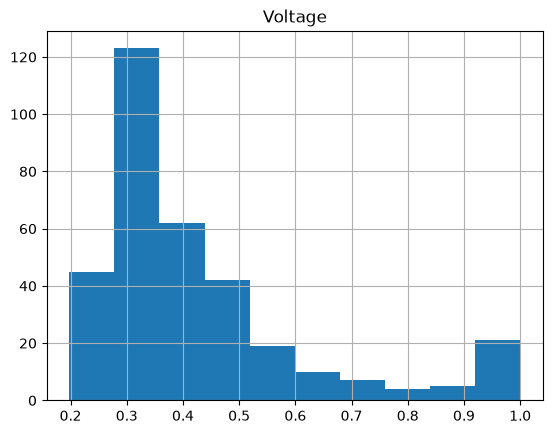

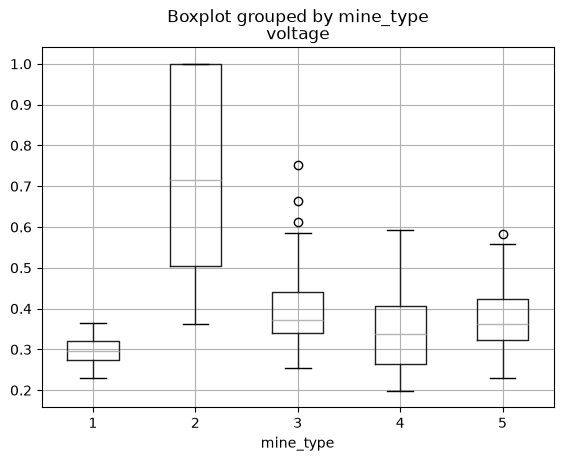

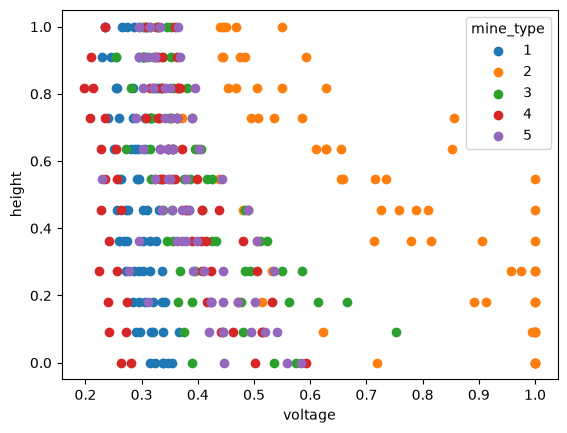

mine_type
1    33
2    35
3    33
4    31
5    37
Name: count, dtype: int64
mine_type
1    38
2    35
3    33
4    35
5    28
Name: count, dtype: int64
Best k: 2   test accuracy: 0.491


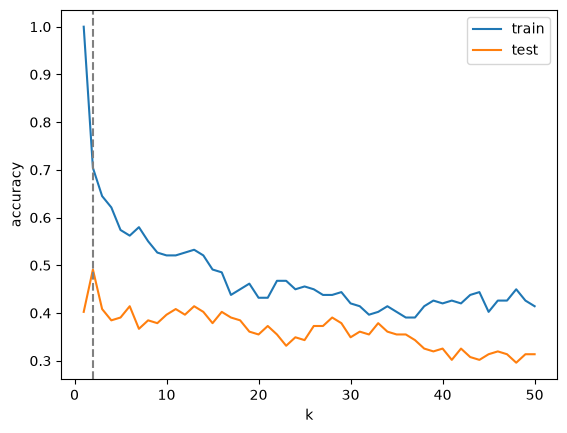

Accuracy: 0.4911242603550296
actual
1    0.736842
2    0.828571
3    0.454545
4    0.257143
5    0.071429
Name: correct, dtype: float64
predicted
1    0.474576
2    0.935484
3    0.300000
4    0.450000
5    0.222222
Name: correct, dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("./data/land_mines.csv")  
print(df.shape)
df.head()

# check for missing values
df.isna().sum()
# target label: how many of each mine type?
df["mine_type"].value_counts().sort_index()
# features
df[["voltage", "height", "soil"]].describe()
# soil only takes 6 values, so it's really a category stored as a number
df["soil"].value_counts().sort_index()
# average of each feature by mine type
df.groupby("mine_type")[["voltage", "height", "soil"]].mean()
df["voltage"].hist()
plt.title("Voltage")
plt.show()

df.boxplot(column="voltage", by="mine_type")
plt.show()

for m in sorted(df["mine_type"].unique()):
    sub = df.loc[df["mine_type"] == m]
    plt.scatter(sub["voltage"], sub["height"], label=str(m))
plt.legend(title="mine_type")
plt.xlabel("voltage")
plt.ylabel("height")
plt.show()

##splitting into training and testing sets
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=100
)

# check that every class shows up in both halves
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())
# scale AFTER splitting 
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

##building knn classifier
ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train, y_train)
    train_acc.append(np.mean(model.predict(X_train) == y_train))
    test_acc.append(np.mean(model.predict(X_test) == y_test))

k_star = int(ks[np.argmax(test_acc)])
print("Best k:", k_star, "  test accuracy:", round(max(test_acc), 3))

plt.plot(ks, train_acc, label="train")
plt.plot(ks, test_acc, label="test")
plt.axvline(k_star, linestyle="--", color="gray")
plt.xlabel("k")
plt.ylabel("accuracy")
plt.legend()
plt.show()

##confusion table
model = KNeighborsClassifier(n_neighbors=k_star)
model.fit(X_train, y_train)
y_hat = model.predict(X_test)

pd.crosstab(y_test, y_hat, rownames=["Actual"], colnames=["Predicted"])
print("Accuracy:", np.mean(y_hat == y_test))

results = pd.DataFrame({"actual": y_test, "predicted": y_hat})
results["correct"] = results["actual"] == results["predicted"]

# of the mines that ARE type m, what share did we get right?
print(results.groupby("actual")["correct"].mean())

# when the model SAYS type m, how often is it right?
print(results.groupby("predicted")["correct"].mean())

##advice
# - Use it as a screening tool, not the final decision.** The model is only about 49% accurate, so it is wrong about half the time. With land mines, a wrong answer can be deadly, so a human expert should always confirm before anyone acts.
# - Only trust a "type 2" prediction.** When the model predicts type 2, it is right 94% of the time, because type 2 mines have much higher voltage than the others. A "type 1" prediction is right only 47% of the time, since many type 4 and 5 mines get labeled type 1.
# - Never use it to rule out a mine type; assume the worst when unsure.** Types 3, 4, and 5 get mixed up with each other and with type 1 (a real type 5 is caught only 7% of the time). If the model predicts anything other than type 2, treat the mine as the most dangerous type it could plausibly be.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]